In [1]:
import os
# os.chdir('case-study')
os.chdir("..")

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
data = pd.read_excel("data/view_export_messungen_2006-11-08.xls")

In [49]:
english_cols = ['id', 'time', 'terminal', 'postal_code', 'municipality', 'district', 'federal_state', 'well_being', 'year_of_birth', 'gender', 'smoker', 'known_blood_sugar', 'known_cholesterol', 'under_treatment', 'estimated_bp_systolic', 'estimated_bp_diastolic', 'measured_bp_systolic', 'measured_bp_diastolic']

In [50]:
# Drop not so important columns
data.drop(['postleitzahl', 'gemeinde', 'bezirk'], axis=1, inplace=True)

In [51]:
# Calculate age at the time of test
data['age'] = 2006 - data['geburtsjahr']

In [52]:
# Analyse how many nulls
data.isna().sum()

id                       0
zeit                     0
terminal                 0
bundesland             331
befinden                23
geburtsjahr             23
geschlecht              23
raucher                  0
blutzucker_bekannt       0
cholesterin_bekannt      0
in_behandlung            0
schaetzwert_bp_sys      45
schaetzwert_by_dia      56
messwert_bp_sys          0
messwert_bp_dia          0
age                     23
dtype: int64

In [53]:
data['schaetzwert_bp_sys'] = data['schaetzwert_bp_sys'].fillna(data['schaetzwert_bp_sys'].mean())
data['schaetzwert_by_dia'] = data['schaetzwert_by_dia'].fillna(data['schaetzwert_by_dia'].mean())

In [54]:
data.head(2)

,id,zeit,terminal,bundesland,befinden,geburtsjahr,geschlecht,raucher,blutzucker_bekannt,cholesterin_bekannt,in_behandlung,schaetzwert_bp_sys,schaetzwert_by_dia,messwert_bp_sys,messwert_bp_dia,age
0,11519,2006-04-27 10:49:12,2,Steiermark,1.0,1967.0,m,False,True,False,False,142.0,89.0,179,111,39.0
1,11520,2006-04-27 11:10:46,2,Steiermark,1.0,1968.0,m,False,False,False,False,140.0,70.0,109,80,38.0
2,11521,2006-04-27 11:21:09,2,Steiermark,1.0,1973.0,m,True,False,False,False,130.0,75.0,128,108,33.0
3,11522,2006-04-27 11:32:59,1,Steiermark,1.0,1961.0,m,False,False,False,False,100.0,80.0,130,90,45.0
4,11524,2006-04-27 12:01:48,2,Steiermark,2.0,1978.0,f,False,False,False,False,140.0,70.0,144,103,28.0


In [27]:
# Check the data for befinden = null
befinden = data[data['befinden'].isna()]

In [36]:
befinden.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23 entries, 2594 to 16374
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   23 non-null     int64         
 1   zeit                 23 non-null     datetime64[ns]
 2   terminal             23 non-null     int64         
 3   bundesland           1 non-null      object        
 4   befinden             0 non-null      float64       
 5   geburtsjahr          0 non-null      float64       
 6   geschlecht           0 non-null      object        
 7   raucher              23 non-null     bool          
 8   blutzucker_bekannt   23 non-null     bool          
 9   cholesterin_bekannt  23 non-null     bool          
 10  in_behandlung        23 non-null     bool          
 11  schaetzwert_bp_sys   21 non-null     float64       
 12  schaetzwert_by_dia   21 non-null     float64       
 13  messwert_bp_sys      23 non-null    

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16386 entries, 0 to 16385
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   16386 non-null  int64         
 1   zeit                 16386 non-null  datetime64[ns]
 2   terminal             16386 non-null  int64         
 3   bundesland           16055 non-null  object        
 4   befinden             16363 non-null  float64       
 5   geburtsjahr          16363 non-null  float64       
 6   geschlecht           16363 non-null  object        
 7   raucher              16386 non-null  bool          
 8   blutzucker_bekannt   16386 non-null  bool          
 9   cholesterin_bekannt  16386 non-null  bool          
 10  in_behandlung        16386 non-null  bool          
 11  schaetzwert_bp_sys   16386 non-null  float64       
 12  schaetzwert_by_dia   16386 non-null  float64       
 13  messwert_bp_sys      16386 non-

In [62]:
df = data

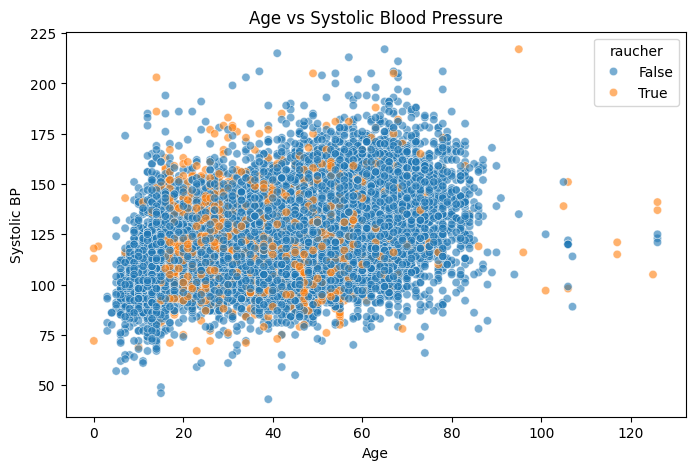

In [131]:
# Age vs BP

plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='age', y='messwert_bp_sys', hue='raucher', alpha=0.6)
# sns.regplot(data=data, x='age', y='messwert_bp_sys', scatter=False, color='black')
plt.title('Age vs Systolic Blood Pressure')
plt.xlabel('Age')
plt.ylabel('Systolic BP')
plt.show()

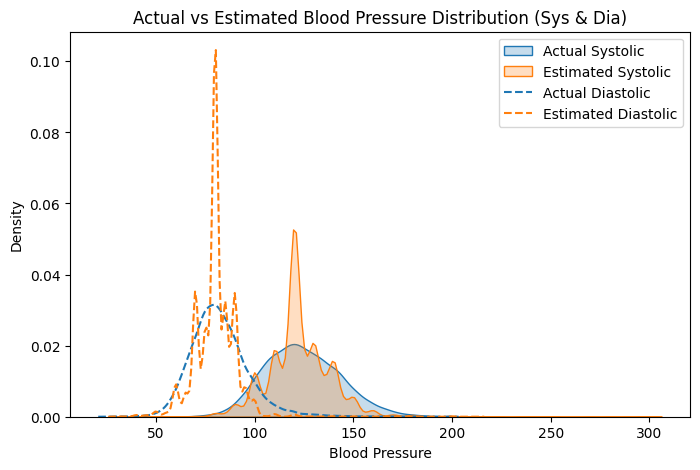

In [130]:
# Actual vs Estimated Blood Pressure (Model Comparison)
plt.figure(figsize=(8,5))

# Systolic
sns.kdeplot(df['messwert_bp_sys'], label='Actual Systolic', fill=True)
sns.kdeplot(df['schaetzwert_bp_sys'], label='Estimated Systolic', fill=True)

# Diastolic
sns.kdeplot(df['messwert_bp_dia'], label='Actual Diastolic', linestyle='--')
sns.kdeplot(df['schaetzwert_by_dia'], label='Estimated Diastolic', linestyle='--')

plt.title('Actual vs Estimated Blood Pressure Distribution (Sys & Dia)')
plt.xlabel('Blood Pressure')
plt.legend()
plt.show()

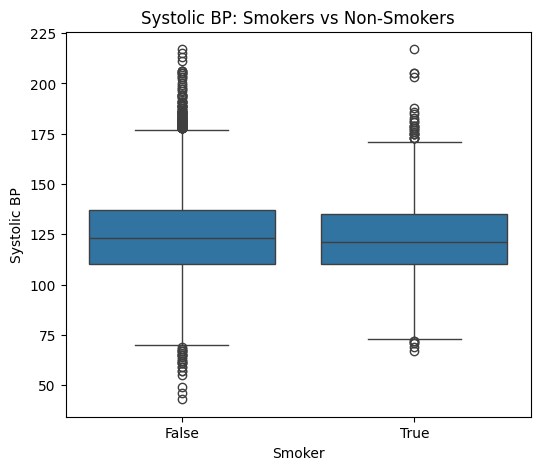

In [64]:
# Smokers vs Non-Smokers (Behavioral Insight)
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='raucher', y='messwert_bp_sys')
plt.title('Systolic BP: Smokers vs Non-Smokers')
plt.xlabel('Smoker')
plt.ylabel('Systolic BP')
plt.show()

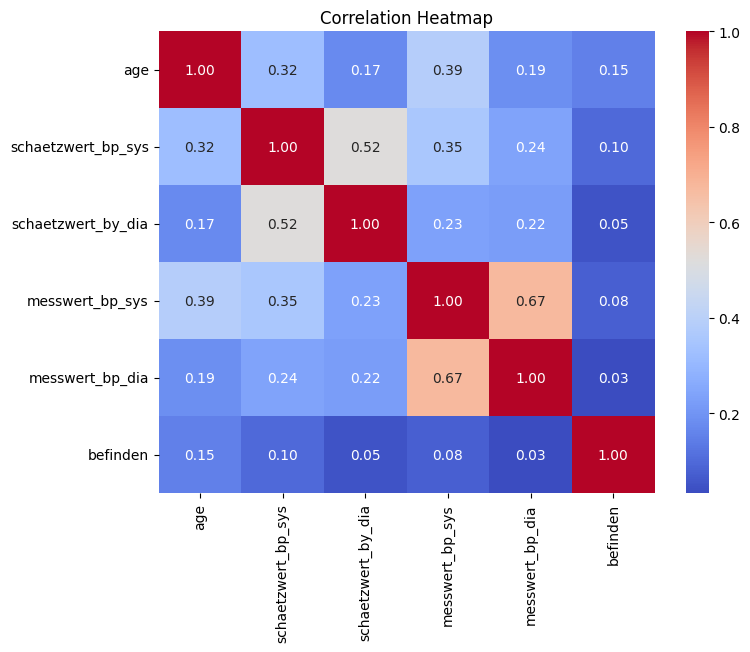

In [65]:
# Correlation Heatmap (Feature Relationships)
import numpy as np

numeric_cols = [
    'age', 'schaetzwert_bp_sys', 'schaetzwert_by_dia',
    'messwert_bp_sys', 'messwert_bp_dia', 'befinden'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

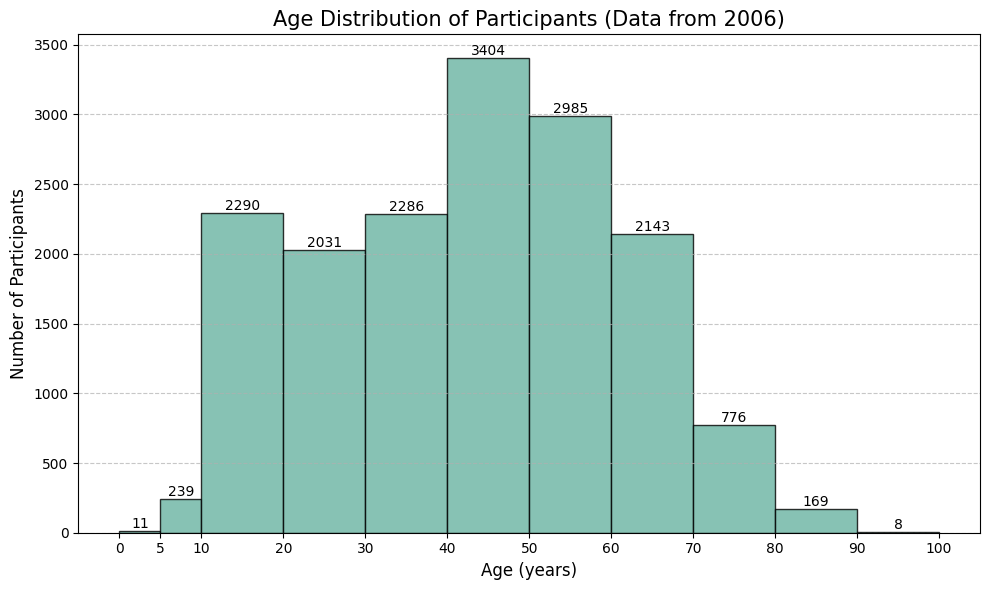

In [87]:
age = data[~data['age'].isna()]['age']

plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(
    age,
    bins=[0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    color='#69b3a2',
    edgecolor='black',
    alpha=0.8
)

# Add labels on top of each bar
for i in range(len(n)):
    plt.text(
        (bins[i] + bins[i+1]) / 2,   # center of bin
        n[i],                        # height of bar
        int(n[i]),                   # label
        ha='center',
        va='bottom'
    )

plt.title('Age Distribution of Participants', fontsize=15)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Participants', fontsize=12)
plt.xticks(bins)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [128]:
len(data[data['age'] <= 15]['raucher'])

1782

Health condition value counts:
 befinden
1.0    5897
2.0    7931
3.0    2240
4.0     198
5.0      97
Name: count, dtype: int64

Gender value counts:
 geschlecht
f    9190
m    7173
Name: count, dtype: int64

Percentage distribution of health condition by gender:
 geschlecht     f     m
befinden              
1.0         35.4  36.8
2.0         48.2  48.8
3.0         14.8  12.3
4.0          1.2   1.2
5.0          0.4   0.8


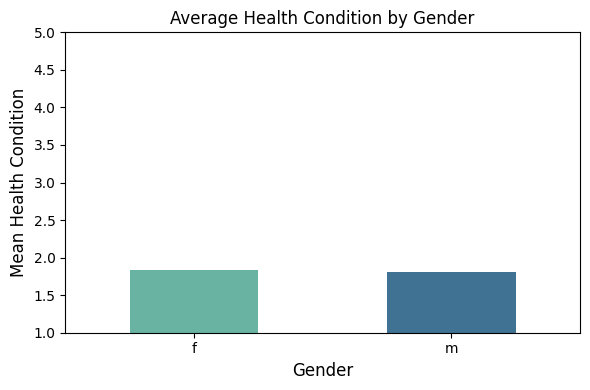

In [12]:
# Exploratory analysis: Relationship between health condition and gender

# Value counts for 'befinden' (health condition)
print("Health condition value counts:\n", data['befinden'].value_counts().sort_index())

# Value counts for 'geschlecht' (gender)
print("\nGender value counts:\n", data['geschlecht'].value_counts())

# Cross-tabulation of health condition by gender
befinden_gender_ct = pd.crosstab(data['befinden'], data['geschlecht'], normalize='columns') * 100
print("\nPercentage distribution of health condition by gender:\n", befinden_gender_ct.round(1))

# Bar plot: Mean health condition by gender (lower is better)
mean_befinden_by_gender = data.groupby('geschlecht')['befinden'].mean()
plt.figure(figsize=(6, 4))
mean_befinden_by_gender.plot(kind='bar', color=['#69b3a2', '#407294'])
plt.ylabel('Mean Health Condition', fontsize=12)
plt.xlabel('Gender', fontsize=12)
plt.title('Average Health Condition by Gender')
plt.xticks(rotation=0)
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

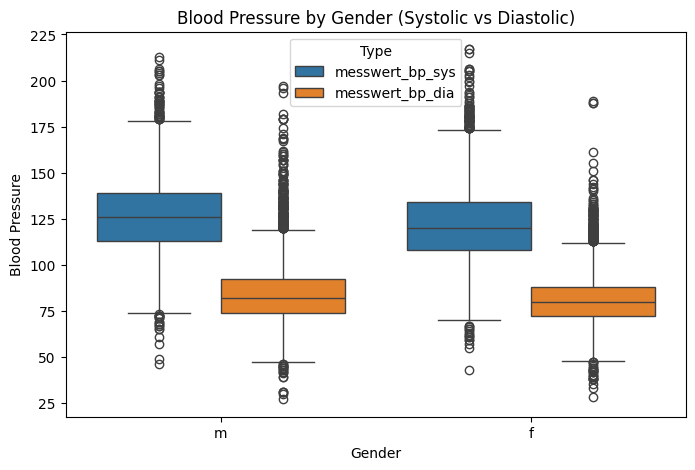

In [133]:
import pandas as pd

# Reshape data
df_melted = df.melt(
    id_vars='geschlecht',
    value_vars=['messwert_bp_sys', 'messwert_bp_dia'],
    var_name='BP_Type',
    value_name='BP_Value'
)

plt.figure(figsize=(8,5))
sns.boxplot(data=df_melted, x='geschlecht', y='BP_Value', hue='BP_Type')
plt.title('Blood Pressure by Gender (Systolic vs Diastolic)')
plt.xlabel('Gender')
plt.ylabel('Blood Pressure')
plt.legend(title='Type')
plt.show()

Health condition value counts:
 befinden
1.0    5897
2.0    7931
3.0    2240
4.0     198
5.0      97
Name: count, dtype: int64

Gender value counts:
 raucher
False    13911
True      2475
Name: count, dtype: int64

Percentage distribution of health condition by gender:
 raucher   False  True 
befinden              
1.0        36.6   32.8
2.0        48.5   48.5
3.0        13.4   15.1
4.0         1.1    1.9
5.0         0.4    1.7


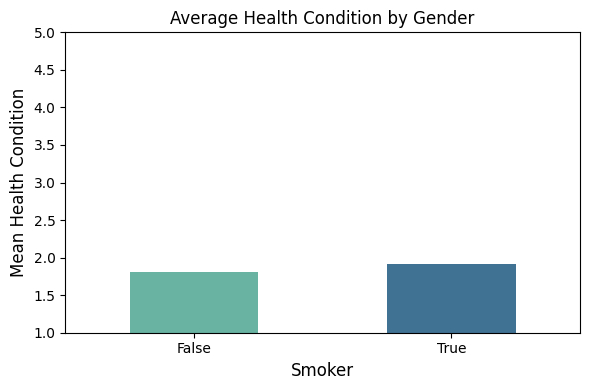

In [14]:
# Exploratory analysis: Relationship between health condition and gender

# Value counts for 'befinden' (health condition)
print("Health condition value counts:\n", data['befinden'].value_counts().sort_index())

# Value counts for 'raucher' (gender)
print("\nGender value counts:\n", data['raucher'].value_counts())

# Cross-tabulation of health condition by gender
befinden_gender_ct = pd.crosstab(data['befinden'], data['raucher'], normalize='columns') * 100
print("\nPercentage distribution of health condition by gender:\n", befinden_gender_ct.round(1))

# Bar plot: Mean health condition by gender (lower is better)
mean_befinden_by_gender = data.groupby('raucher')['befinden'].mean()
plt.figure(figsize=(6, 4))
mean_befinden_by_gender.plot(kind='bar', color=['#69b3a2', '#407294'])
plt.ylabel('Mean Health Condition', fontsize=12)
plt.xlabel('Smoker', fontsize=12)
plt.title('Average Health Condition by Gender')
plt.xticks(rotation=0)
plt.ylim(1, 5)
plt.tight_layout()
plt.show()